### scratch and code experiments

In [574]:
G = nx.fast_gnp_random_graph(10, 0.4, seed=12)
H = nx.fast_gnp_random_graph(5, 0.7, seed=14)
# nx.draw_spring(G, with_labels=True)

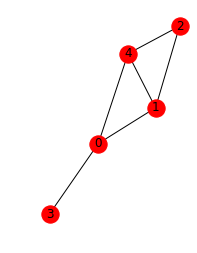

In [1405]:
plt.subplot(121)
nx.draw_spring(H, with_labels=True)

from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Show/hide code"></form>''')



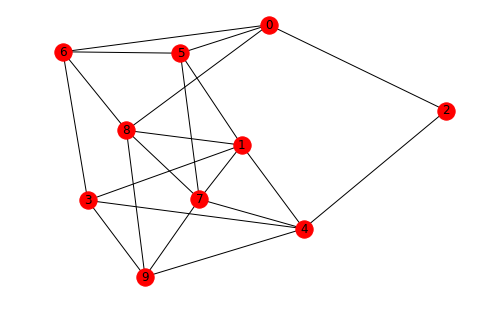

In [350]:
# plt.subplot(121)
nx.draw_spring(G, with_labels=True)

In [ ]:
H2 = nx.Graph()
H2.add_nodes_from([0,1,2,3,4,5])
H2.add_edges_from([(0,1), (1, 2), (2, 0), (4, 3), (3, 5), (5, 4), (0, 3)])
nx.draw_spring(H2, with_labels=True)

In [ ]:
T = nx.Graph()
T.add_nodes_from(range(12))
T.add_edges_from([(0,1), (1,2), (1,3), (6,4), (2,5), (5,6), (5,7), (3,8), (8,9), (8,10), (2,11)])
nx.draw_spring(T, with_labels=True)

## CONSOLE(ATION)

In [144]:
import numpy as np
import pandas as pd
import networkx as nx
import functions_dynamic as fn
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
import cProfile as cp
import random as rnd
import permanent as per
import operator
importlib.reload(fn)
G = nx.fast_gnp_random_graph(10, 0.4, seed=12)
H = nx.fast_gnp_random_graph(5, 0.7, seed=14)

######################################################################

# maps = fn.findSubgraphInstances(H, G, True)
# [tuple(f.getMap()) for f in maps]

### dynamic algorithm

In [186]:
# early abort using degree, neighbor degree sequence, onion layer and
# coreness
def canSupport(h, g, H, G):
    
    if(G.degree(g) >= H.degree(h)):
        neighborsH = sortDegrees(H, H[h])
        neighborsG = sortDegrees(G, G[g])
        neighborsH = np.array(list(reversed(neighborsH)), dtype=[('node', 'i4'), ('degree', 'i4')])
        neighborsG = np.array(list(reversed(neighborsG)), dtype=[('node', 'i4'), ('degree', 'i4')])

        minn = min(len(neighborsH), len(neighborsG))

        for i in range(minn):
            if(neighborsG['degree'][i] < neighborsH['degree'][i]):
                return False
            
        return True

    return False


class DynamicTree():
    
    def __init__(self, G, root):
        self.dict = {root: {'parent': None,
                            'children': [],
                            'table': {0: set(G.nodes()).remove(root)}},
                    'root': root,
                    'leaves': [root]}
        
        self.graph = G
        
        
    def __getitem__(self, key):
        return self.dict[key]
    
    
    def __setitem__(self, key, value):
        self.dict[key] = value
        
        
    def addNode(self, node, parent):
        if (node in self.dict.keys()):
            print('node already added')
        
        else:
            v = node[len(node)-1]
            self.dict[node] = {'parent': parent,
                               'children': [],
                               'table': {0: self.dict[parent]['table'][0].remove(v)}}

            self.dict[parent]['children'].append(node)
            self.dict['leaves'].remove(parent)
            self.dict['leaves'].append(node)
            
            
    def removeNode(self, node):
        if (node not in self.dict.keys()):
            print('node not in tree')
            
        else:
            p = self.dict[node]['parent']
            self.dict[p]['children'].remove(node)
            
            if self.dict[node]['children']:
                for child in self.dict[node]['children']:
                    self.removeNode[child]
        
            del self.dict[node]
            
            if node in self.dict['leaves']:
                self.dict['leaves'].remove(node)
                
                
    def depth(self, node):
        r = self.dict['root']
        n = node
        path = []
        
        while(n != r):
            path.append(n)
            n = self.dict[n]['parent']
            
        return len(path)
    
    
    def getTable(self, node):
        return self.dict[node]['table']
    
    
    def setTable(self, node, k, value):
        self.dict[node]['table'][k] = value
        
        
    def leaves(self):
        return self.dict['leaves']
    
    
    def parent(self, node):
        return self.dict[node]['parent']
    
    
    def children(self, node):
        return self.dict[node]['children']
    

    def printTree(self):
        print(self.dict)
    


In [238]:
# adapted to iterative dynamic implementation of isomorphicExtensions
def findSubgraphInstances_dynamic(H, G, withSBC=True):
    
    instances = []
    
    # adds onion layer, coreness and traversal attributes to G and H
    traversal_order_G = fn.onionDecompose(G)
    traversal_order_H = fn.onionDecompose(H)
    
    # last node to be peeled off in H
    k = traversal_order_H[len(H)-1]
    
    # traverse G in increasing onion layer
    for i in range(len(G)):
        g = traversal_order_G[i]

        if(canSupport(k, g, H, G)):
            instances.append(isomorphicExtensions_dynamic(g, H, G))
    
    return instances


# a dynamic implementation of isomorphic extensions
def isomorphicExtensions_dynamic(g, H, G, M=None):
    
    instances = []
    traversal = {}
    
    for i in H.nodes():
        traversal[i] = H.nodes(i)['traversal']
     
                      # variables initialization #
        
    t = len(H)-1                            # initial traversal index
    h = traversal[t]      # last node peeled off is first to traverse
    f = fn.Map([(h, g)])                        # initial partial map
    D = {h}                                  # initial partial domain
    R = {f.applyMap(h)}                       # initial partial range
    m = h                                  # initial domain extension
    nmD = D.intersection(set(H[m]))             # neighbors of m in D
    fnmD = set([f.applyMap(i) for i in nmD]) # images of nmD elements
    c = H.nodes(m)['coreness']         # coreness of domain extension
    
    candidateTree = DynamicTree(G, g)
    leaves = candidateTree['leaves'][:]
    
    
                  # computing isomorphism candidates #
    
    for l in leaves:     # leaves are in fact paths from root to leaf
        v = l[len(l)-1]             # actual leaf, candidate for f(m)
        p = candidateTree[l]['parent']       # parent of current leaf
        
        if (l == candidateTree['root']):
            candidateTree[l]['table'][1] = set(G[v])
            candidateTree[l]['table'][2] = set()
            
        else:
            loopEnd = min(c, len(D))+1
        
            for i in range(1, loopEnd):        # [0] is non-neighbors
                N_ip1_R = set(candidateTree[p]['table'][i])
                N_i_R = set(candidateTree[p]['table'][i-1])
                N_v = set(G[v])

                newEntry = N_ip1_R.union(N_i_R.intersection(N_v)).difference(N_ip1_R.intersection(N_v))
                candidateTree[l]['table'][i] = newEntry
            
            candidateTree[l]['table'][loopEnd] = set()
    
        N_k = candidateTree[l]['table'][k]     # get N_k neighborhood
        
        
                        # testing isomorphism #
        
        if not N_k:                       # N_k neighborhood is empty
            while ((len(candidateTree[p]['children']) == 1) or p == candidateTree['root']):
                f = p
                p = candidateTree[p]['parent']
            
            candidateTree.removeNode(f)
            
        else:
            for i in N_k:
                if (set(G[i]).intersection(D) == fnmD):   # O(|G[i]|)
                    temp = list(l)
                    temp.append(i)
                    newNode = tuple(temp)
                    candidateTree.addNode(newNode, l)
                    
        if (l == leaves[len(leaves)-1]):               # last element
            if (len(D) == len(H)):                         # all done
                for leaf in leaves:
                    instances.append[leaf]
                
                return instances
            
            D = D.union({m})
            t = t - 1
            m = traversal[t]
            leaves = candidateTree['leaves']
        

### subtree isomorphism ideas:

#### recursive bipartite matching

In [374]:
# returns a list of depths with the sorted degree sequence of the 
# vertices at that depth
def depthDegreeSequence(T, root):
    paths = nx.single_source_shortest_path(T, root)
    seq = {}
    longestPath = max([len(v) for v in paths.values()])

    for i in range(1, longestPath+1):
        seq[i] = set()

    for key in paths.keys():
        path = paths[key]
        l = len(path)
        seq[l] = seq[l].union({key})

    for key in seq.keys():
        degrees = sorted([len(T[v])-1 for v in seq[key] if key != 1])
        seq[key] = [i for i in reversed(degrees)]
        
    seq[1] = [len(T[root])]
        
    print(seq)
    return seq

# returns the subtree of T rooted at r with parent p
def subtree(T, r, p):
    K = nx.Graph()
    K.add_edges_from(T.edges())
    K.remove_edge(r, p)

    for k in nx.connected_components(K):
        if (r in k):
            F = nx.Graph()
            
            if (len(k) == 1):
                F.add_node(r)
            else:
                for i in k:
                    for j in k:
                        if ((i, j) in K.edges()):
                            F.add_edge(i, j)

    return F                


# recursively counts the matchings of the bipartite graphs obtained
# from subtree isomorphisms between subtrees of T and subtrees of S
def countMatchings(T, rootT, S, rootS, init=True):
#     print('count matchings call')
#     print('rootT: ',end='')
#     print(rootT)
#     print('rootS: ',end='')
#     print(rootS)
#     print(T.nodes())
#     print(S.nodes())
    parentT = rootT
    parentS = rootS
    childrenT = set(T[rootT]).difference({rootT})
    childrenS = set(S[rootS]).difference({rootS})
    G = nx.Graph()
    
    # base case
    if (not childrenT):
        return 1
    
    if (len(childrenT) > len(childrenS)):
        return 0
    
    index_i = 0
    index_j = len(childrenT)
    
    for i in childrenT:
        for j in childrenS:
            if (i >= j):
                Ti = subtree(T, i, rootT)
                Sj = subtree(S, j, rootS)
                k = countMatchings(Ti, i, Sj, j, False)
                G.add_edge(index_i, index_j, weight = k)
            index_j += 1
        index_i += 1
                
    M = nx.to_numpy_matrix(G)
    D = nx.to_dict_of_dicts(G)
    
    if (init):
        pos = nx.bipartite_layout(G, childrenT)
        nx.draw_networkx_nodes(G, pos)
        nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)
        _dict_ = {}
        _dict2_ = {}
        
        for n in G.edges():
            if (D[n[0]][n[1]]['weight']):
                _dict_[n] = D[n[0]][n[1]]['weight']
        
        for n in G.nodes():
            _dict2_[n] = n
                
        nx.draw_networkx_edge_labels(G, pos, edge_labels=_dict_, font_size=8)
        nx.draw_networkx_labels(G, pos, labels=_dict2_, font_size=8)
        
    return per.permanent(M)


# recursively find the number of induced subtrees of H's depth-1
# branches and apply bipartite matching to count the number of
# possible matches.
def countRootedSubtrees(T, rootT, S, rootS):
    count = 0
    
    # early abort by root degree
    if (len(T[rootT]) > len(S[rootS])):
        print('early abort: root degree')
        return count
    
    # early abort by depth
    if (nx.eccentricity(T, rootT) > nx.eccentricity(S, rootS)):
        print('early abort: max depth')
        return count
    
    seqT = depthDegreeSequence(T, rootT)
    seqS = depthDegreeSequence(S, rootS)
    
    for i in seqT.keys():
        # early abort by number of nodes at each depth
        if (len(seqT[i]) > len(seqS[i])):
            print('early abort: number of depth-k nodes')
            return count
        
        # early abort by node degree sequence at each depth
        for k, v in enumerate(seqT[i]):
            if (v > seqS[i][k]):
                print('early abort: depth-k degree sequence')
                return count
        
    # recursion
    return countMatchings(T, rootT, S, rootS)
                

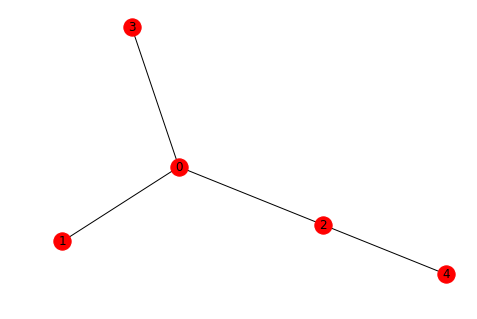

In [323]:
T = randomTree(5, 2)
S = randomTree(10, 2)

nx.draw(T, with_labels=True)

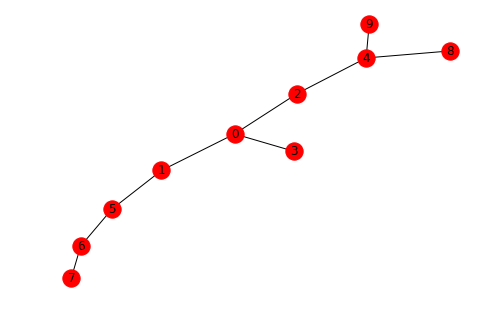

In [324]:
nx.draw(S, with_labels=True)

{1: [3], 2: [1, 0, 0], 3: [0]}
{1: [3], 2: [1, 1, 0], 3: [2, 1], 4: [1, 0, 0], 5: [0]}


0.0

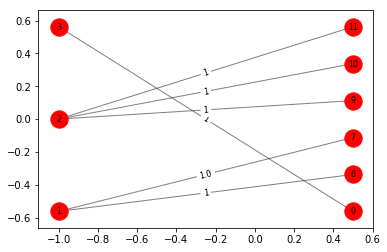

In [375]:
countRootedSubtrees(T, 0, S, 0)


In [325]:
F = nx.Graph()
F.add_node(1)
set(F[1]).difference({1})

set()

In [353]:
F = nx.Graph()
F.add_edge(1, 0, weight=1)
# F.add_edge(1, 2, weight=1)
F.add_edge(1, 4, weight=1)
# F.add_edge(1, 6, weight=1)
F.add_edge(3, 0, weight=1)
# F.add_edge(3, 2, weight=3)
F.add_edge(3, 4, weight=1)
# F.add_edge(3, 6, weight=1)
F.add_edge(3, 8, weight=1)
# F.add_edge(5, 0, weight=1)
F.add_edge(5, 2, weight=1)
# F.add_edge(5, 4, weight=2)
F.add_edge(5, 6, weight=1)
# F.add_edge(7, 0, weight=1)
# F.add_edge(7, 2, weight=1)
F.add_edge(7, 4, weight=1)
# F.add_edge(7, 6, weight=1)
F.add_edge(9, 0, weight=1)
F.add_edge(9, 2, weight=1)
F.add_edge(9, 4, weight=1)
F.add_edge(9, 6, weight=1)
F.add_edge(9, 8, weight=1)
M = nx.to_numpy_matrix(F)
# print(M)
# print(per.permanent(M))
# nx.draw(F, with_labels=True)
# nx.max_weight_matching(F)
nx.to_dict_of_dicts(F)

[1, 1, 0, 0, 4, 4, 4, 3, 8, 5, 5, 2, 6]

In [294]:
math.factorial(4)

24

In [189]:
print([i for i in range(10)])
print([i for i in range(10, 20)])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


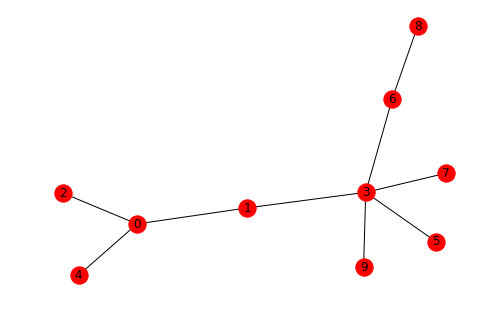

In [166]:
T = randomTree(10, 1)
nx.draw_spring(T, with_labels=True)

#### string matching

In [25]:
# try taking advantage of linear subtree isomorphism

# generate random trees
def randomTree(n, seed):
    rnd.seed(seed)
    
    T = nx.Graph()
    T.add_node(0)
    
    for i in range(1, n):
        r = rnd.randint(0,i-1)
        T.add_edge(r, i)
    
    return T


# # return the preorder traversal of a tree rooted at 'root'
# def findPreorderString(T, node, parent):
#     string = ''
    
#     if(node == parent):
#         children = set(T[parent])

#     else:
#         children = set(T[node]).difference({parent})
        
#     if(children):
#         for n in children:
#             s = '1'
#             s = s + findPreorderString(T, n, node)
#             s = s + '0'
#             string = string + s
    
#     else:
#         return ''

#     return string


# # decompose a string into levels each corresponding to a tree depth
# def levelDecompose(t, s):
#     if (len(s) < len(t)):
#         return False
    
#     depthS = s.find('0')
#     depthT = t.find('0')
    
#     D = {}
    
#     for i in range(depthS):
#         D[i] = ''

#     level = 0
#     inc = 0
#     prevInc = 0
    
#     for k in s:
#         prevInc = inc
#         inc = 2*int(k) - 1
        
#         if(k == '0'):
#             level = level + inc
            
#         if(prevInc + inc == 0):
#             D[level] = D[level][:-1]
        
#         D[level] = D[level] + k + ' '
            
#         if(k == '1'):
#             level = level + inc
            
#     return D


# # finds whether two sequences are isomorphic given their
# # level decomposition and the length of S
# def subsequenceIsomorphism(dictT, dictS, lenS)
#     maxLevelS = max(dictS.keys())
#     maxLevelT = max(dictT.keys())
    
#     if (maxLevelS < maxLevelT):
#         return False
    
#     minIndex = 0
#     maxIndex = lenS
    
#     for l in range(maxLevelT, -1, -1):
#         bounds = matchLayer(dictS[l], dictT[l], minIndex, maxIndex)
        
#         if(bounds == None):
#             return False
        
#         minIndex = bounds[0]
#         maxIndex = bounds[1]
        
#     return True
        

# # returns lower and upper bounds between which to search for the next
# # match in higher layers, null if no match
# def matchLayer(strT, strS, minIndex, maxIndex):
#     t = strT[minIndex:maxIndex]
#     s = strS
                
#     c = re.compile()
    

# # test subtree isomorphism on T and S
# def subtreeIsomorphism(T, S, t, s):
#     strT = compressTree(T, t, t)
#     strS = compressTree(S, s, s)
#     print(strT)
#     print(strS)
    
#     n = len(strT)
#     m = len(strS)
    
#     return matchSequence(strT, strS, n, m)


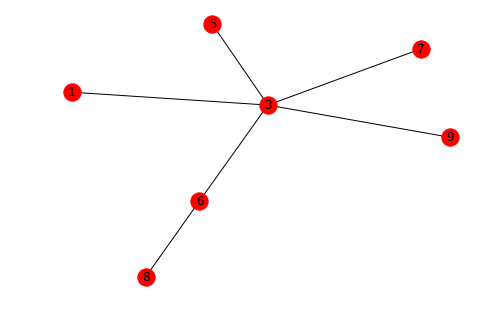

In [187]:
F = subtree(T, 1, 0
           )
nx.draw_spring(F, with_labels=True)

In [ ]:
T = randomTree(5)
S = randomTree(10)
nx.draw_spring(T, with_labels=True)


In [ ]:
nx.draw_spring(S, with_labels=True)

In [1190]:
t = ''
s = '1111101000100111100100101000'

subsequenceIsomorphism(t, s)


{0: '1 0 ', 1: '1 01 0 ', 2: '1 010 1 01010 ', 3: '1 0 1 010 ', 4: '1010 10 '}


In [142]:
import permanent as per
importlib.reload(per)

per.main()

give the dimension : 10
a random 0/1-matrix :
 [[1 0 1 1 1 0 1 0 0 0]
 [0 1 0 0 0 0 1 0 0 1]
 [1 0 0 1 0 0 1 1 0 1]
 [0 0 1 0 0 0 1 0 1 0]
 [0 0 1 0 0 1 0 0 1 1]
 [0 0 0 1 0 1 1 1 1 0]
 [0 1 0 1 1 1 0 1 0 1]
 [0 1 1 1 0 0 1 1 0 0]
 [0 0 1 1 1 1 1 0 0 1]
 [1 1 0 1 1 0 0 0 0 1]]
permanent : 1908


In [1193]:
[i for i in range(3, 0, -1)]

[3, 2, 1]

In [24]:
f1 = fn.Map([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5)])
f2 = fn.Map([(0, 0), (1, 1), (2, 2), (3, 3), (4, 5), (5, 4)])
f3 = fn.Map([(0, 0), (1, 2), (2, 1), (3, 3), (4, 4), (5, 5)])
f4 = fn.Map([(0, 0), (1, 2), (2, 1), (3, 3), (4, 5), (5, 4)])
f5 = fn.Map([(0, 3), (1, 4), (2, 5), (3, 0), (4, 1), (5, 2)])
f6 = fn.Map([(0, 3), (1, 5), (2, 4), (3, 0), (4, 2), (5, 1)])

# autH2 = [f1, f2, f3, f4, f5, f6]  # set of automorphisms of H2
# eq = fn.findEquivalenceClasses(autH2)
# M = fn.symmetryConditions(autH2)

# [t for t in f1.getMap()]